In [1]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
import re

# Save all data_prep figures into data/data_prep_plots
PLOTS_DIR = os.path.join("data", "data_prep_plots") if os.path.isdir("data") else "data_prep_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
from pathlib import Path
DATA_DIR = Path(".")

## 0. Data Collection 

In [3]:
# ！！！Original code to get data. As this is time-consuming, I already saved it as "HMDA_CA_TX_2019_2024_Master.csv". And you donot 
# need to run this cell for further steps. 
# print("Starting the [CA+TX] Data Engine (2019-2024)...")

# # 1. set years to 2019-2024
# years = ['2019', '2020', '2021', '2022', '2023', '2024']
# target_states = "CA,TX"

# # 2. Proportional Stratified Sampling Rate
# # By applying the EXACT SAME fraction (1%) to both classes independently, 
# # we mathematically guarantee Proportional Stratified Sampling.
# # This ensures the final dataset perfectly maintains the real-world ratio of Approved vs Denied.
# SAMPLE_FRACTION = 0.01 

# all_sampled_data = []

# for year in years:
#     print(f"\n ================= Fetching {year} ================= ")
    
#     # ---------------------------------------------------------
#     # Stratum 1: Originated Loans (Approved)
#     # ---------------------------------------------------------
#     url_originated = f"https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states={target_states}&years={year}&actions_taken=1"
#     try:
#         df_1 = pd.read_csv(url_originated, low_memory=False)
#         # Apply stratified sampling for Stratum 1
#         df_1 = df_1.sample(frac=SAMPLE_FRACTION, random_state=42)
#         # Manually assign the positive label (1 = Approved)
#         df_1['target_y'] = 1  
#         all_sampled_data.append(df_1)
#         print(f"Stratum 1 (Approved): Sampled {len(df_1):,} rows.")
        
#         # Free up memory
#         del df_1
#         gc.collect()
#     except Exception as e:
#         print(f"Failed to fetch Stratum 1 data for {year}: {e}")
        
#     # ---------------------------------------------------------
#     # Stratum 2: Denied Loans
#     # ---------------------------------------------------------
#     url_denied = f"https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states={target_states}&years={year}&actions_taken=3"
#     try:
#         df_3 = pd.read_csv(url_denied, low_memory=False)
#         # Apply stratified sampling for Stratum 2 using the SAME fraction
#         df_3 = df_3.sample(frac=SAMPLE_FRACTION, random_state=42)
#         # Manually assign the negative label (0 = Denied)
#         df_3['target_y'] = 0  
#         all_sampled_data.append(df_3)
#         print(f"Stratum 2 (Denied): Sampled {len(df_3):,} rows.")
        
#         # Free up memory
#         del df_3
#         gc.collect()
#     except Exception as e:
#         print(f" Failed to fetch Stratum 2 data for {year}: {e}")

# print("\n🔄 Merging all strata and years into the final Master dataset...")
# # Concatenate all datasets
# final_df = pd.concat(all_sampled_data, ignore_index=True)

# print("\n🏆 --- Final Master Dataset Statistics ---")
# print(f"Total rows: {len(final_df):,}")
# print("\nTarget Distribution (Perfectly mirrors reality due to Stratified Sampling):")
# print(final_df['target_y'].value_counts(normalize=True))

# # Export the master dataset
# final_df.to_csv("HMDA_CA_TX_2019_2024_Master.csv", index=False)
# print("\n Success! Dataset saved as 'HMDA_CA_TX_2019_2024_Master.csv'")

## 1. Rough EDA + Cleaning

#### read raw data

In [4]:
final_df = pd.read_csv(DATA_DIR / "HMDA_CA_TX_2019_2024_Master.csv", low_memory=False)

# Snapshot the raw predictors table for Fig4 funnel counts
df_raw_loaded = final_df.copy()

print(final_df.shape)
print(final_df.head(3))

(139991, 100)
   activity_year                   lei  derived_msa-md state_code  \
0           2019  KB1H1DSPRFMYMCUFXT09           44700         CA   
1           2019  5493001SXWZ4OFP8Z903           26420         TX   
2           2019  7H6GLXDRUGQFU57RNE97           41700         TX   

   county_code  census_tract conforming_loan_limit derived_loan_product_type  \
0       6077.0  6.077001e+09                     C   Conventional:First Lien   
1      48201.0  4.820154e+10                     C            FHA:First Lien   
2      48029.0  4.802912e+10                     C   Conventional:First Lien   

              derived_dwelling_category       derived_ethnicity  ...  \
0  Single Family (1-4 Units):Site-Built      Hispanic or Latino  ...   
1  Single Family (1-4 Units):Site-Built      Hispanic or Latino  ...   
2  Single Family (1-4 Units):Site-Built  Not Hispanic or Latino  ...   

  denial_reason-3 denial_reason-4  tract_population  \
0             NaN             NaN           

In [5]:
print(list(final_df.columns))

['activity_year', 'lei', 'derived_msa-md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affordable_units', 'income', 'debt_to_income_ratio', 'applicant_credit_score

## 1.1. Dtype Formatting

In [6]:
df_final = final_df.copy()

# Drop obvious label-leakage and post-outcome fields
leakage_cols = ['action_taken', 'purchaser_type', 'denial_reason-1', 'denial_reason-2', 'denial_reason-3', 'denial_reason-4',
                "interest_rate",
    "rate_spread",
    "total_loan_costs",
    "origination_charges",
    "discount_points",
    "lender_credits",
    "hoepa_status",
    "total_points_and_fees",
]
df_final.drop(columns=leakage_cols, errors='ignore', inplace=True)

# Convert activity_year to covid_phase categories
if 'activity_year' in df_final.columns:
    years = pd.to_numeric(df_final['activity_year'], errors='coerce')
    conditions = [years <= 2019, years <= 2021, years > 2021]
    choices = ['Pre-Pandemic', 'Peak-Pandemic', 'Post-Pandemic']

    # numpy.select requires all choices/default to share a common dtype.
    # Use a string default for missing/unknown years.
    # np.select returns a numpy array → cast via pandas to StringDtype.
    df_final['covid_phase'] = pd.Series(
        np.select(conditions, choices, default='Unknown'),
        index=df_final.index,
        dtype='string',
    )
    df_final.drop(columns=['activity_year'], inplace=True)
    print("✅ 'activity_year' converted to 'covid_phase' and dropped.")

# Define numeric columns for type casting
numeric_cols = [
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units",
]

# Convert target variable type
if 'target_y' in df_final.columns:
    df_final['target_y'] = pd.to_numeric(df_final['target_y'], errors='coerce').astype('Int8')

# Convert numeric columns to appropriate types
for col in numeric_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Convert categorical columns to string and standardize missing values
categorical_cols = [c for c in df_final.columns if c not in numeric_cols and c != 'target_y']
for col in categorical_cols:
    df_final[col] = df_final[col].astype('string').replace({'nan': pd.NA, 'NaN': pd.NA, 'None': pd.NA})

# -------------------------------
# Convert variable types and process DTI missing/ordinal features
# -------------------------------

# Standardized missing values list
coded_missing_values = ["", "NA", "N/A", "Exempt", "<NA>", "nan", "NaN", "None"]

# Format loan_term as numeric and treat coded string values as missing
if "loan_term" in df_final.columns:
    df_final["loan_term"] = pd.to_numeric(
        df_final["loan_term"].astype("string").str.strip().replace(coded_missing_values, pd.NA),
        errors="coerce"
    )

# Process debt_to_income_ratio: create missing flag and ordered numeric mapping
if "debt_to_income_ratio" in df_final.columns:
    dti_clean = df_final["debt_to_income_ratio"].astype("string").str.strip().replace(coded_missing_values, pd.NA)
    
    # Missing flag creation
    df_final["dti_missing_flag"] = dti_clean.isna().astype(int)

    dti_map = {
        "<20%": 15, "20%-<30%": 25, "30%-<36%": 33, "36": 36, "36%": 36, "37": 37,
        "37%": 37, "38": 38, "38%": 38, "39": 39, "39%": 39, "40": 40, "40%": 40,
        "41": 41, "41%": 41, "42": 42, "42%": 42, "43": 43, "43%": 43, "44": 44,
        "44%": 44, "45": 45, "45%": 45, "46": 46, "46%": 46, "47": 47, "47%": 47,
        "48": 48, "48%": 48, "49": 49, "49%": 49, "50%-60%": 55, ">60%": 65
    }

    df_final["debt_to_income_ratio_ord"] = dti_clean.map(dti_map).astype("float64")
    df_final.drop(columns=["debt_to_income_ratio"], errors="ignore", inplace=True)

# Snapshot after leakage removal and type coercions
df_post_leak = df_final.copy()
final_df = df_final

✅ 'activity_year' converted to 'covid_phase' and dropped.


## 1.2. find & drop cols with high missing rate

In [7]:
# Identify features with >80% missing values
print("Finding features with High Missing Values (>80% missing)")
missing_pct = final_df.isnull().mean() * 100
cols_to_drop_missing = missing_pct[missing_pct > 80].sort_values(ascending=False)

print(cols_to_drop_missing)
print("We will drop these columns because they lack sufficient data to train a robust model. Filling them would introduce massive bias.\n")
print(f"🗑️ Dropping {len(cols_to_drop_missing)} columns due to >80% missing rates...")

# Drop high missing rate columns and assign to new dataframe
df_cleaned = final_df.drop(columns=cols_to_drop_missing.index)

# Snapshot after >80% missing drop
df_post_missing = df_cleaned.copy()

print("✅ Drop successful!")
print(f"Original columns: {final_df.shape[1]}")
print(f"Remaining columns: {df_cleaned.shape[1]}")

Finding features with High Missing Values (>80% missing)
co-applicant_ethnicity-4        99.998571
co-applicant_ethnicity-5        99.998571
applicant_ethnicity-5           99.997857
applicant_ethnicity-4           99.995714
co-applicant_race-5             99.995714
applicant_race-5                99.982856
co-applicant_race-4             99.973570
co-applicant_ethnicity-3        99.944282
applicant_race-4                99.939282
applicant_ethnicity-3           99.829989
co-applicant_race-3             99.741412
aus-5                           99.391389
applicant_race-3                99.346387
aus-4                           99.310670
multifamily_affordable_units    98.412041
aus-3                           98.227743
prepayment_penalty_term         96.106893
co-applicant_race-2             95.879735
co-applicant_ethnicity-2        95.492567
aus-2                           91.633748
applicant_race-2                90.462244
applicant_ethnicity-2           89.603617
intro_rate_period  

## 1.3. Explore & deal with cols with high cardinality

In [8]:
# Ensure loan_term and ordinal DTI are treated as numeric
if 'loan_term' in df_cleaned.columns:
    df_cleaned['loan_term'] = pd.to_numeric(df_cleaned['loan_term'], errors='coerce')

if 'debt_to_income_ratio_ord' in df_cleaned.columns:
    df_cleaned['debt_to_income_ratio_ord'] = pd.to_numeric(df_cleaned['debt_to_income_ratio_ord'], errors='coerce')

# Define continuous columns to exclude from cardinality checks
continuous_cols = [
    'loan_amount', 'income', 'property_value', 'interest_rate',
    'rate_spread', 'total_loan_costs', 'loan_to_value_ratio',
    'origination_charges', 'discount_points', 'lender_credits', 'tract_population',
    'tract_minority_population_percent', 'ffiec_msa_md_median_family_income',
    'tract_to_msa_income_percentage', 'tract_owner_occupied_units',
    'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units',
    'loan_term', 'debt_to_income_ratio_ord',

    "debt_to_income_ratio_ord",
]

# Calculate unique value counts for categorical columns only
categorical_unique_counts = df_cleaned.nunique().drop(labels=continuous_cols, errors='ignore').sort_values(ascending=False)

# Identify and drop high-cardinality categorical columns (>8 unique values)
DROP_THRESHOLD = 8
high_card_cols = categorical_unique_counts[categorical_unique_counts > DROP_THRESHOLD]

print(f"ACTION 1: Found {len(high_card_cols)} categorical columns with > {DROP_THRESHOLD} unique values (Auto-Dropping):")
print(high_card_cols)

df_cleaned.drop(columns=high_card_cols.index, errors='ignore', inplace=True)

# Snapshot after high-cardinality drop
df_post_highcard = df_cleaned.copy()

# Identify columns needing manual review or consolidation (5-8 unique values)
REVIEW_LOW, REVIEW_HIGH = 5, 8
review_cols = categorical_unique_counts[(categorical_unique_counts >= REVIEW_LOW) & 
                                        (categorical_unique_counts <= REVIEW_HIGH)]

print(f"\nACTION 2: Found {len(review_cols)} columns with {REVIEW_LOW} to {REVIEW_HIGH} unique values (Needs Consolidation):")
print(review_cols)

print("\n--- Validation ---")
print(f"Is 'loan_term' retained? {'loan_term' in df_cleaned.columns}")
print(f"Is 'debt_to_income_ratio' retained? {'debt_to_income_ratio' in df_cleaned.columns}")

ACTION 1: Found 12 categorical columns with > 8 unique values (Auto-Dropping):
census_tract                      16693
lei                                1553
county_code                         301
derived_msa-md                       59
co-applicant_race-1                  19
applicant_race-1                     18
co-applicant_credit_score_type       15
applicant_credit_score_type          14
co-applicant_ethnicity-1              9
total_units                           9
derived_race                          9
co-applicant_age                      9
dtype: int64

ACTION 2: Found 9 columns with 5 to 8 unique values (Needs Consolidation):
applicant_age                               8
derived_loan_product_type                   8
applicant_ethnicity-1                       8
aus-1                                       8
co-applicant_sex                            6
manufactured_home_land_property_interest    6
loan_purpose                                6
derived_ethnicity             

### Further look at the features w/ unique values [5,8]---- EDA

📊 Generating Approval Rate Analysis by Category...


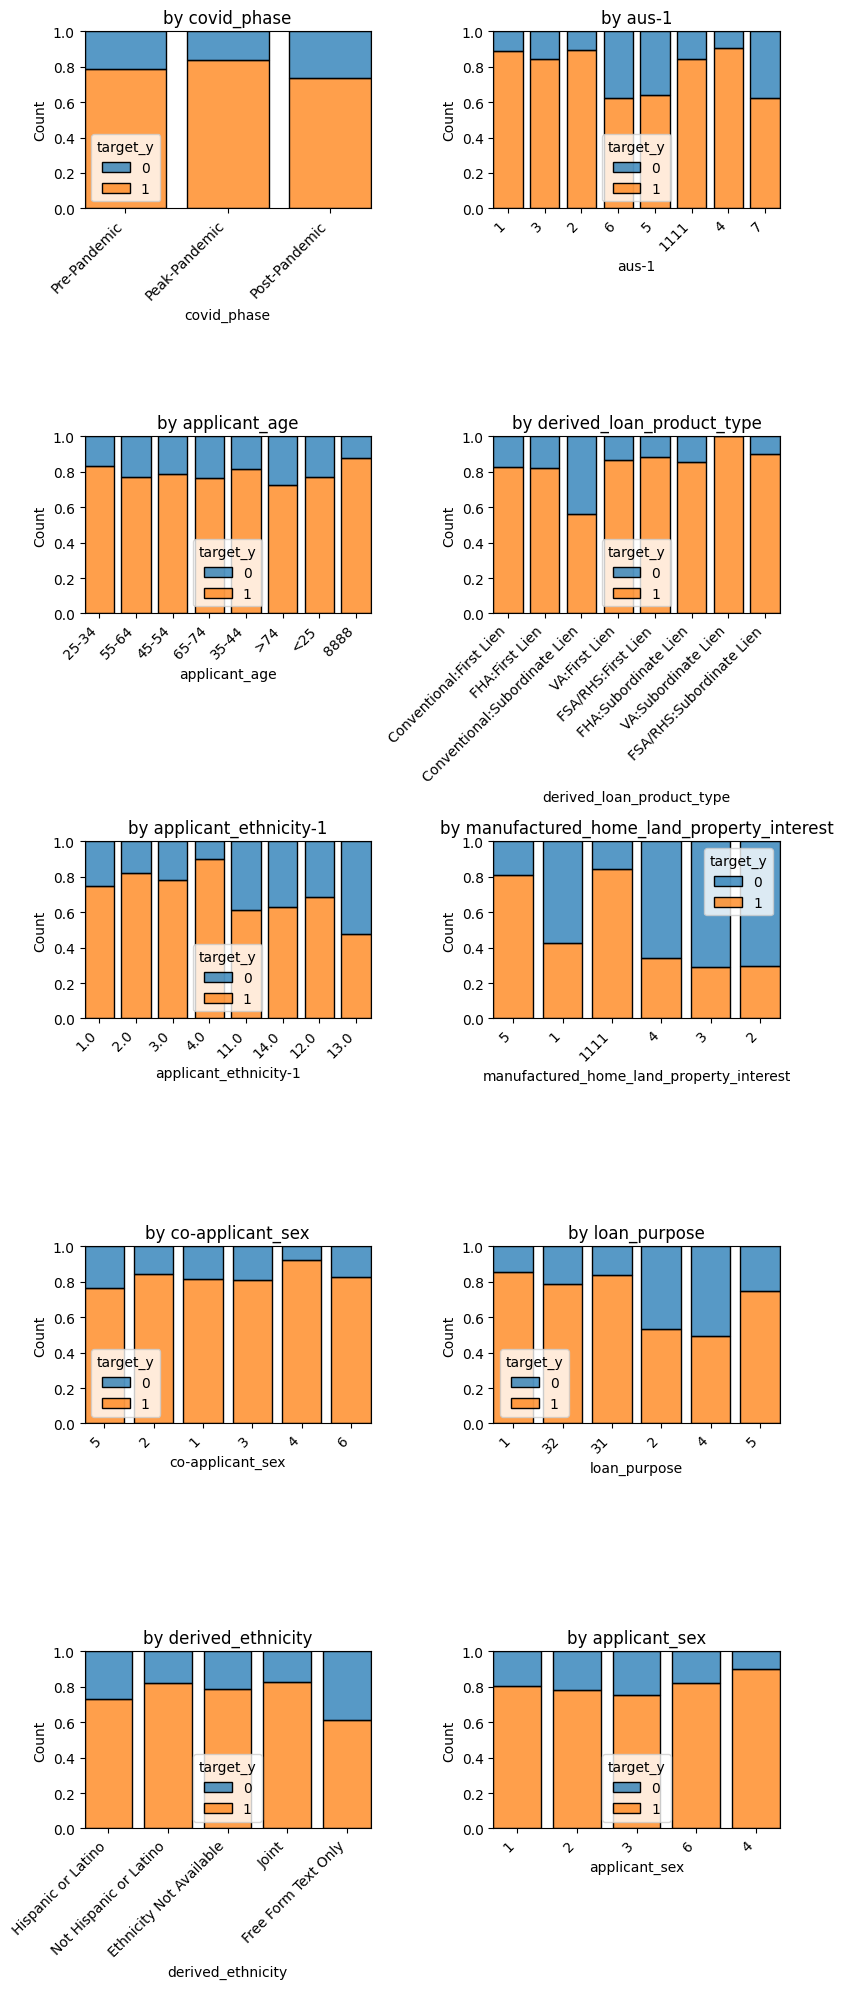

In [9]:
# Create an independent copy for visualization to preserve original dtypes
df_plot = df_cleaned.copy()

# Ensure categorical consistency for proper axis label rendering
cols_to_fix = ['aus-1', 'loan_purpose', 'manufactured_home_land_property_interest', 
               'applicant_ethnicity-1', 'applicant_sex', 'co-applicant_sex']
valid_cols = [c for c in cols_to_fix if c in df_plot.columns]
df_plot[valid_cols] = df_plot[valid_cols].astype(str)

# Define variables for Approval Rate inspection
target_cols = [
    'covid_phase', 'aus-1', 'applicant_age', 'derived_loan_product_type', 
    'applicant_ethnicity-1', 'manufactured_home_land_property_interest', 
    'co-applicant_sex', 'loan_purpose', 'derived_ethnicity', 'applicant_sex'
]

print("📊 Generating Approval Rate Analysis by Category...")

# Generate stacked percentage distributions to evaluate impact on target_y
plt.figure(figsize=(8, 20))
for i, col in enumerate(target_cols):
    if col in df_plot.columns:
        plt.subplot(5, 2, i+1)
        sns.histplot(data=df_plot, x=col, hue='target_y', multiple="fill", shrink=.8)
        plt.title(f'by {col}', fontsize=12)
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [10]:
# Binning aus-1 based on sharp visual difference in approval rates
df_cleaned['aus_grouped'] = np.where(
    df_cleaned['aus-1'].astype(str).isin(['1', '2', '3', '4']), 
    'Standard_AUS', 
    'Non_Standard_or_Exempt'
)

# Binning applicant_age into broader groups and treating 8888/9999 as NaN
age_map = {
    '<25': '<25', '25-34': '25-44', '35-44': '25-44', 
    '45-54': '>44', '55-64': '>44', '65-74': '>44', '>74': '>44'
}
df_cleaned['applicant_age_grouped'] = df_cleaned['applicant_age'].astype(str).map(age_map)

# Binning derived_loan_product_type by Lien status due to massive variance
product_type_str = df_cleaned['derived_loan_product_type'].astype(str)
conditions = [
    product_type_str.str.contains('First Lien', na=False),
    product_type_str.str.contains('Subordinate Lien', na=False)
]
df_cleaned['loan_product_grouped'] = np.select(
    conditions, 
    ['First_Lien', 'Subordinate_Lien'], 
    default='Other'
)

# Grouping manufactured_home_land_property_interest by High approval vs High denial
df_cleaned['manufactured_home_grouped'] = np.where(
    df_cleaned['manufactured_home_land_property_interest'].astype(str).isin(['5', '1111']),
    'Not_Applicable_or_Exempt',
    'Has_Property_Interest'
)

# Grouping co-applicant_sex by presence of co-applicant (5 = No co-applicant)
df_cleaned['is_joint_application'] = np.where(
    df_cleaned['co-applicant_sex'].astype(str) == '5', 
    0, 
    1
)

# Binning loan_purpose into high-risk purposes (2, 4) vs standard
df_cleaned['loan_purpose_grouped'] = np.where(
    df_cleaned['loan_purpose'].astype(str).isin(['2', '4']),
    'High_Risk_Purpose',
    'Standard_Purpose'
)

# Drop variables with near-zero variance, redundancy, or those replaced by groupings
cols_to_drop = [
    'aus-1', 
    'applicant_age', 
    'derived_loan_product_type', 
    'manufactured_home_land_property_interest', 
    'co-applicant_sex', 
    'loan_purpose', 
    'applicant_sex', 
    'applicant_ethnicity-1'
]
df_final = df_cleaned.drop(columns=cols_to_drop, errors='ignore')

print("--- Data Processing Complete ---")
print(f"Final columns: {df_final.columns.tolist()}")
print(f"Count of NaN in 'applicant_age_grouped' (previously 8888/9999): {df_final['applicant_age_grouped'].isna().sum()}")

--- Data Processing Complete ---
Final columns: ['state_code', 'conforming_loan_limit', 'derived_dwelling_category', 'derived_ethnicity', 'derived_sex', 'preapproval', 'loan_type', 'lien_status', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio', 'loan_term', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'income', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex_observed', 'co-applicant_sex_observed', 'applicant_age_above_62', 'co-applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 't

## 1.4. Drop Zero / Near-Zero Variance Features(We Split Train & Test Set Here)

In [11]:
# Split data (decision metrics calculated on TRAIN only to strictly prevent data leakage)
X = df_final.drop(columns=['target_y'])
y = df_final['target_y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify feature types
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# Define variance thresholds
NUM_STD_THRESHOLD = 0.03
CAT_DOMINANCE_THRESHOLD = 0.98

cols_to_drop_low_var = []
drop_reasons = {}

# Evaluate numeric features: vectorized temporary median imputation and standard deviation check
numeric_low_var = []
if numeric_cols:
    train_num_filled = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
    num_stds = train_num_filled.std(ddof=0)
    
    numeric_low_var = num_stds[num_stds <= NUM_STD_THRESHOLD].index.tolist()
    for c in numeric_low_var:
        drop_reasons[c] = f"[NUM] {c}: std={num_stds[c]:.6g}"

# Evaluate categorical features: temporary mode imputation and dominance check
categorical_low_var = []
for c in categorical_cols:
    s = X_train[c].astype('string')
    if s.isna().any():
        mode_vals = s.dropna().mode()
        fill_val = mode_vals.iloc[0] if not mode_vals.empty else "<MISSING>"
        s = s.fillna(fill_val)
    
    vc = s.value_counts(normalize=True, dropna=False)
    top_share = float(vc.iloc[0]) if not vc.empty else 1.0
    n_unique = len(vc)
    
    if top_share >= CAT_DOMINANCE_THRESHOLD or n_unique <= 1:
        categorical_low_var.append(c)
        reason = "1-unique" if n_unique <= 1 else f"top_share>={CAT_DOMINANCE_THRESHOLD}"
        drop_reasons[c] = f"[CAT] {c}: {reason}, n_unique={n_unique}, top_share={top_share:.4f}"

# Combine and sort features tagged for removal
cols_to_drop_low_var = sorted(numeric_low_var + categorical_low_var)

print("--- Low-variance feature scan (decided on TRAIN only) ---")

# Output detailed reasons for dropped features (up to 10)
if cols_to_drop_low_var:
    print(f"\nColumns to drop (showing up to 10 out of {len(cols_to_drop_low_var)}):")
    for c in cols_to_drop_low_var[:10]:
        print(f"  {drop_reasons[c]}")
else:
    print("\nNo low-variance columns found with current thresholds.")

print("\n--- Summary ---")
print("(Counts below are computed on TRAIN only.)")
print(f"Numeric near-constant cols (std <= {NUM_STD_THRESHOLD}): {len(numeric_low_var)}")
print(f"Categorical near-constant cols (top share >= {CAT_DOMINANCE_THRESHOLD} or 1-unique): {len(categorical_low_var)}")
print(f"TOTAL to drop: {len(cols_to_drop_low_var)}")

--- Low-variance feature scan (decided on TRAIN only) ---

Columns to drop (showing up to 10 out of 4):
  [CAT] negative_amortization: top_share>=0.98, n_unique=3, top_share=0.9860
  [CAT] other_nonamortizing_features: top_share>=0.98, n_unique=3, top_share=0.9808
  [CAT] preapproval: top_share>=0.98, n_unique=2, top_share=0.9838
  [CAT] reverse_mortgage: top_share>=0.98, n_unique=3, top_share=0.9809

--- Summary ---
(Counts below are computed on TRAIN only.)
Numeric near-constant cols (std <= 0.03): 0
Categorical near-constant cols (top share >= 0.98 or 1-unique): 4
TOTAL to drop: 4


### Figure 5 — Geographic Distribution (EDA)

- Placed here to validate CA vs TX differences on the same training split.
- Uses a log scale for loan amount density to make the long tail interpretable.


In [12]:
# Align EDA data to the TRAIN split to prevent data leakage
assert "df_cleaned" in globals() and "X_train" in globals() and "y_train" in globals()

BLUE, TEAL, AMBER, ROSE, GRAY, BG, TEXT_LO = (
    globals().get("BLUE", "#2563EB"), globals().get("TEAL", "#0D9488"),
    globals().get("AMBER", "#D97706"), globals().get("ROSE", "#E11D48"),
    globals().get("GRAY", "#9CA3AF"), globals().get("BG", "#F8FAFC"),
    globals().get("TEXT_LO", "#64748B")
)

print("Rendering fig5_geographic.png ...")

df_geo = df_cleaned.loc[X_train.index].copy()
df_geo["target_y"] = y_train.values

if "state_code" not in df_geo.columns:
    raise KeyError("state_code not found in df_cleaned; cannot run Fig5 geographic distribution")

ca = df_geo[df_geo["state_code"] == "CA"]
tx = df_geo[df_geo["state_code"] == "TX"]

fig5, axes5 = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG, gridspec_kw={"wspace": 0.32})
fig5.subplots_adjust(top=0.84, bottom=0.14, left=0.07, right=0.97)
fig5.suptitle("Geographic Distribution — California vs Texas", fontsize=14, fontweight="bold", y=0.98)

# ---------------------------------------------------------
# Left Subplot: Sample Size & Approval Rate
# ---------------------------------------------------------
ax = axes5[0]
counts = [len(ca), len(tx)]
approvals = [ca["target_y"].mean() * 100, tx["target_y"].mean() * 100]

x = np.arange(2)
w = 0.30

# Plot sample counts (bars, left axis)
bars_cnt = ax.bar(x, counts, w * 1.2, color=[BLUE, TEAL], alpha=0.85, edgecolor="white", zorder=3)

# Plot approval rates as points + connecting line (right axis)
ax_r = ax.twinx()
ax_r.plot(x, approvals, color=GRAY, lw=1.2, alpha=0.6, zorder=2)
ax_r.scatter(x, approvals, s=45, c=[AMBER, ROSE], edgecolor="white", linewidth=0.9, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(["California (CA)", "Texas (TX)"], fontsize=10)
ax.set_ylabel("Sample count", fontsize=10, color=TEXT_LO)
ax_r.set_ylabel("Approval rate (%)", fontsize=10, color=TEXT_LO)
# Keep approval-rate axis visually stable and not exaggerated.
ax_r.set_ylim(70, 85)
ax_r.set_yticks([70, 73, 76, 79, 82, 85])
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Annotate sample counts (inside bars)
for b in bars_cnt:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h * 0.52,
        f"{int(h):,}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
    )

# Annotate approval rates near points
for xi, y in zip(x, approvals):
    xoff = 12 if xi == 0 else -12
    ha = "left" if xi == 0 else "right"
    ax_r.annotate(
        f"{y:.1f}%",
        xy=(xi, y),
        xytext=(xoff, 0),
        textcoords="offset points",
        ha=ha,
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#000000",
    )

# Render custom legend
handles = [
    mpatches.Patch(color=BLUE, label="CA — sample count (bar, left axis)"),
    mpatches.Patch(color=TEAL, label="TX — sample count (bar, left axis)"),
    mlines.Line2D([], [], color=AMBER, marker="o", linestyle="None", markersize=6, label="CA — approval rate (point, right axis)"),
    mlines.Line2D([], [], color=ROSE, marker="o", linestyle="None", markersize=6, label="TX — approval rate (point, right axis)"),
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, framealpha=0, fontsize=9)
ax.set_title("Sample size & approval rate", loc="left", fontsize=11.5, fontweight="bold")

# ---------------------------------------------------------
# Right Subplot: Loan Amount Distribution (log1p KDE)
# ---------------------------------------------------------
ax = axes5[1]
if "loan_amount" not in df_geo.columns:
    ax.axis("off")
    ax.text(0.5, 0.5, "loan_amount not available", ha="center", va="center")
else:
    # Generate log1p distributions
    x_ca = np.log1p(ca["loan_amount"].dropna())
    x_tx = np.log1p(tx["loan_amount"].dropna())

    # Utilize seaborn for optimized KDE rendering
    sns.kdeplot(x=x_ca, ax=ax, color=BLUE, fill=True, alpha=0.18, linewidth=2.0, bw_method=0.15)
    sns.kdeplot(x=x_tx, ax=ax, color=TEAL, fill=True, alpha=0.18, linewidth=2.0, bw_method=0.15)

    # Plot median markers
    med_ca, med_tx = float(np.median(x_ca)), float(np.median(x_tx))
    ax.axvline(med_ca, color=BLUE, ls=":", lw=1.5)
    ax.axvline(med_tx, color=TEAL, ls=":", lw=1.5)

    ax.set_xlabel("log1p(loan_amount)", fontsize=10, color=TEXT_LO)
    ax.set_ylabel("Density", fontsize=10, color=TEXT_LO)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    # Render combined legend for KDE and medians
    legend_elements = [
        mlines.Line2D([], [], color=BLUE, lw=2.0, label="CA (log1p KDE)"),
        mlines.Line2D([], [], color=TEAL, lw=2.0, label="TX (log1p KDE)"),
        mlines.Line2D([], [], color=BLUE, lw=1.5, ls=":", label=f"CA median={med_ca:.2f}"),
        mlines.Line2D([], [], color=TEAL, lw=1.5, ls=":", label=f"TX median={med_tx:.2f}")
    ]
    ax.legend(handles=legend_elements, framealpha=0, fontsize=9)
    ax.set_title("Loan amount distribution — CA vs TX", loc="left", fontsize=11.5, fontweight="bold")

fig5_path = os.path.join(PLOTS_DIR, "fig5_geographic.png")
fig5.savefig(fig5_path, dpi=300, bbox_inches="tight", facecolor=BG)
print(f"  → Saved {fig5_path}")
plt.close(fig5)

Rendering fig5_geographic.png ...
  → Saved data_prep_plots/fig5_geographic.png


In [13]:
# Apply the feature removal determined from the TRAIN split to the entire dataset
df_final_before = df_final.shape
df_final.drop(columns=cols_to_drop_low_var, errors='ignore', inplace=True)

print("\n✅ Applied low-variance drop to df_final")
print(f"df_final shape: {df_final_before} -> {df_final.shape}")

# Re-split the updated dataset to ensure X_train and X_test reflect the dropped columns
X = df_final.drop(columns=['target_y'])
y = df_final['target_y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train/Test shapes: {X_train.shape} | {X_test.shape}")


✅ Applied low-variance drop to df_final
df_final shape: (139991, 50) -> (139991, 46)
Train/Test shapes: (111992, 45) | (27999, 45)


## 1.5. Imputation

#### viz current missing values via heatmap

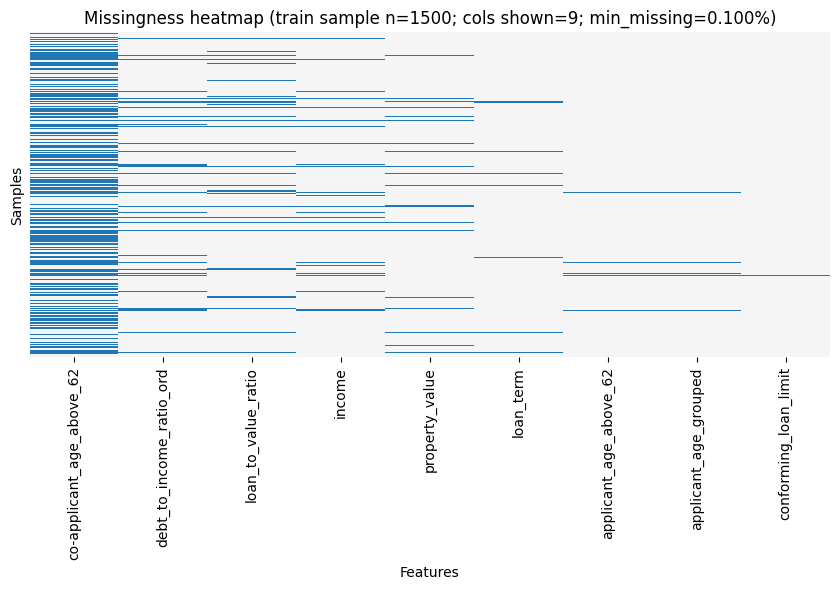

Top missing-rate features shown (train, before imputation) [%]:
co-applicant_age_above_62    54.06
debt_to_income_ratio_ord      9.74
loan_to_value_ratio           8.89
income                        7.03
property_value                4.97
loan_term                     2.57
applicant_age_above_62        1.50
applicant_age_grouped         1.50
conforming_loan_limit         0.48
dtype: float64


In [14]:
TOP_K_COLS, HEATMAP_N_ROWS, MIN_MISSING_RATE = 35, 1500, 0.001

# Calculate missing rates for features in the training set
missing_rate = X_train.isna().mean()
missing_nonzero = missing_rate[missing_rate > 0].sort_values(ascending=False)

# Filter features with >0.1% missingness, fallback to any >0
missing_focus = missing_nonzero[missing_nonzero >= MIN_MISSING_RATE]
if missing_focus.empty:
    missing_focus = missing_nonzero

cols_show = missing_focus.head(TOP_K_COLS).index.tolist()

if not cols_show:
    print("No missing values found in X_train.")
else:
    # Sample training data for heatmap visualization
    X_show = X_train[cols_show]
    if len(X_show) > HEATMAP_N_ROWS:
        X_show = X_show.sample(n=HEATMAP_N_ROWS, random_state=42)

    # Render missingness heatmap
    plt.figure(figsize=(min(10, 0.5 * len(cols_show) + 4), 6))
    sns.heatmap(
        X_show.isna().astype(int),
        cmap=sns.color_palette(["#f5f5f5", "#1f77b4"], as_cmap=True),
        cbar=False,
        yticklabels=False,
    )
    
    plt.title(f"Missingness heatmap (train sample n={len(X_show)}; cols shown={len(cols_show)}; min_missing={MIN_MISSING_RATE:.3%})")
    plt.xlabel("Features")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.show()

    print('Top missing-rate features shown (train, before imputation) [%]:')
    print((missing_focus.head(TOP_K_COLS) * 100).round(2))

In [15]:
print("--- 1.5 Missing-Value Imputation (Fit on TRAIN only) ---")

TRAIN_CACHE_PATH = "after1.5-train.csv"
TEST_CACHE_PATH = "after1.5-test.csv"

# Force median imputation for specific ordinal/discrete columns
force_median_cols = ["loan_term", "debt_to_income_ratio_ord"]

cache_loaded = False

# 1. Strict Cache Loading
if os.path.exists(TRAIN_CACHE_PATH) and os.path.exists(TEST_CACHE_PATH):
    try:
        X_train_cache = pd.read_csv(TRAIN_CACHE_PATH, index_col=0)
        X_test_cache = pd.read_csv(TEST_CACHE_PATH, index_col=0)
        
        # Only use cache if columns are an EXACT match. Otherwise, recompute to ensure integrity.
        if list(X_train_cache.columns) == list(X_train.columns):
            X_train_imputed = X_train_cache
            X_test_imputed = X_test_cache
            cache_loaded = True
            print(f"✅ Exact cache match found. Loaded {TRAIN_CACHE_PATH} and {TEST_CACHE_PATH}")
    except Exception as e:
        print(f"⚠️ Failed to read cache: {e}")

# 2. Imputation Computation (if no cache or columns changed)
if not cache_loaded:
    print("🔄 No valid cache found or features changed. Computing imputation...")
    
    numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

    X_train_imputed = X_train.copy()
    X_test_imputed = X_test.copy()

    # --- A. Numeric: KNN Imputation (Scaled) ---
    numeric_missing = [c for c in numeric_cols if X_train[c].isna().any()]
    
    # Predictors that help KNN make better guesses
    related_numeric = [
    "property_value",
    "loan_amount",
    "income",
    "loan_to_value_ratio",
    "debt_to_income_ratio_ord",
]
    
    # Exclude force-median columns from KNN overwrite
    knn_cols = sorted(set(numeric_missing + related_numeric).intersection(numeric_cols))
    knn_cols = [c for c in knn_cols if c not in force_median_cols]

    if knn_cols:
        print(f"  -> Running KNN Imputation on {len(knn_cols)} numeric columns...")
        scaler = StandardScaler()
        knn_imp = KNNImputer(n_neighbors=5, weights="distance")

        # Scale -> Impute -> Inverse Scale (Fit on Train, Transform on Test)
        X_train_knn = scaler.fit_transform(X_train[knn_cols])
        X_test_knn = scaler.transform(X_test[knn_cols])

        X_train_imputed[knn_cols] = scaler.inverse_transform(knn_imp.fit_transform(X_train_knn))
        X_test_imputed[knn_cols] = scaler.inverse_transform(knn_imp.transform(X_test_knn))

    # --- B. Categorical: Mode Imputation ---
    if categorical_cols:
        print(f"  -> Running Mode Imputation on {len(categorical_cols)} categorical columns...")
        mode_imp = SimpleImputer(strategy="most_frequent")

        # sklearn SimpleImputer can choke on pandas StringDtype + pd.NA ("boolean value of NA is ambiguous").
        # Convert to object and represent missing as np.nan first.
        X_train_cat = X_train[categorical_cols].astype("object").where(~X_train[categorical_cols].isna(), np.nan)
        X_test_cat = X_test[categorical_cols].astype("object").where(~X_test[categorical_cols].isna(), np.nan)

        X_train_imputed[categorical_cols] = pd.DataFrame(
            mode_imp.fit_transform(X_train_cat),
            columns=categorical_cols,
            index=X_train.index,
        )
        X_test_imputed[categorical_cols] = pd.DataFrame(
            mode_imp.transform(X_test_cat),
            columns=categorical_cols,
            index=X_test.index,
        )

# 3. Force-Median Overwrite (Applied to BOTH loaded cache and newly computed data)
print(f"  -> Forcing median imputation for: {force_median_cols}")
for c in set(force_median_cols).intersection(X_train.columns):
    med_val = pd.to_numeric(X_train[c], errors="coerce").median()
    if pd.notna(med_val):
        # Fill only the values that were ORIGINALLY missing in X_train / X_test
        X_train_imputed.loc[X_train[c].isna(), c] = med_val
        X_test_imputed.loc[X_test[c].isna(), c] = med_val

# 4. Save to Cache
print(f"💾 Saving outputs to cache...")
X_train_imputed.to_csv(TRAIN_CACHE_PATH, index=True)
X_test_imputed.to_csv(TEST_CACHE_PATH, index=True)

# 5. Sanity Checks
print("\n--- Imputation Sanity Checks ---")
print(f"Any NA in X_train_imputed? {X_train_imputed.isna().any().any()}")
print(f"Any NA in X_test_imputed?  {X_test_imputed.isna().any().any()}")
print(f"X_train_imputed shape: {X_train_imputed.shape}")
print(f"X_test_imputed shape:  {X_test_imputed.shape}")

--- 1.5 Missing-Value Imputation (Fit on TRAIN only) ---
✅ Exact cache match found. Loaded after1.5-train.csv and after1.5-test.csv
  -> Forcing median imputation for: ['loan_term', 'debt_to_income_ratio_ord']
💾 Saving outputs to cache...

--- Imputation Sanity Checks ---
Any NA in X_train_imputed? False
Any NA in X_test_imputed?  False
X_train_imputed shape: (111992, 45)
X_test_imputed shape:  (27999, 45)


### Figure 1 — Imputation Validation (EDA, placed after 1.5)

- This is the active Fig1 location: right after imputation and before log/winsor.


In [16]:
# FIG 1 — Imputation Validation (KDE Before vs After)
# Before: raw X_train (with missing)
# After : X_train_imputed (post-imputation, pre-log)


BLUE   = globals().get("BLUE", "#2563EB")
CORAL  = globals().get("CORAL", "#F97316")
VIOLET = globals().get("VIOLET", "#7C3AED")
TEAL   = globals().get("TEAL", "#0D9488")
AMBER  = globals().get("AMBER", "#D97706")
BG     = globals().get("BG", "#F8FAFC")
TEXT_HI = globals().get("TEXT_HI", "#0F172A")
TEXT_LO = globals().get("TEXT_LO", "#64748B")
BORDER  = globals().get("BORDER", "#E2E8F0")
PANEL   = globals().get("PANEL", "#FFFFFF")

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": BORDER,
    "axes.facecolor": PANEL,
    "figure.facecolor": BG,
    "grid.color": BORDER,
    "grid.linewidth": 0.6,
    "xtick.color": TEXT_LO,
    "ytick.color": TEXT_LO,
    "text.color": TEXT_HI,
})

def fig_header(fig, title, subtitle=""):
    fig.suptitle(title, fontsize=14, fontweight="bold", color=TEXT_HI, y=0.99)
    if subtitle:
        fig.text(0.5, 0.955, subtitle, ha="center", fontsize=9.5, color=TEXT_LO, wrap=True)

def ax_header(ax, title, note=""):
    ax.set_title(title, fontsize=11.5, fontweight="bold", color=TEXT_HI, loc="left", pad=6)
    if note:
        ax.text(0.0, 1.055, note, transform=ax.transAxes, fontsize=8, color=TEXT_LO, va="bottom", ha="left", style="italic")

assert "X_train_imputed" in globals(), "Run 1.5 imputation before Fig1."

print("Rendering fig1_imputation.png ...")

fig1, axes1 = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG, gridspec_kw={"wspace": 0.30})
fig1.subplots_adjust(top=0.84, bottom=0.12, left=0.07, right=0.97)
fig_header(fig1, "Imputation Validation — KDE Before vs After")

# Left: Income
ax = axes1[0]
income_before = X_train["income"].dropna()
income_after = X_train_imputed["income"].dropna()

cap = income_before.quantile(0.99)
obs_c = income_before[income_before <= cap]
imp_c = income_after[income_after <= cap]

kde_b = stats.gaussian_kde(obs_c, bw_method=0.15)
kde_a = stats.gaussian_kde(imp_c, bw_method=0.15)
xg = np.linspace(0, cap, 500)

ax.fill_between(xg, kde_b(xg), alpha=0.15, color=BLUE)
ax.fill_between(xg, kde_a(xg), alpha=0.15, color=CORAL)
ax.plot(xg, kde_b(xg), lw=2.0, color=BLUE, label=f"Before (n={len(obs_c):,})")
ax.plot(xg, kde_a(xg), lw=2.0, color=CORAL, ls="--", label=f"After (n={len(imp_c):,})")

income_med = obs_c.median()
ax.axvline(income_med, color=AMBER, lw=1.6, ls=":", label=f"Observed Median = {income_med:.0f}k")

ax.set_xlabel("Income (×$1 k)", fontsize=10, color=TEXT_LO)
ax.set_ylabel("Density", fontsize=10, color=TEXT_LO)
ax.legend(fontsize=8.5, framealpha=0, loc="upper right", bbox_to_anchor=(1.0, 0.62))
ax_header(ax, "Income", f"Missing {X_train['income'].isna().mean()*100:.1f}% · imputation pipeline")

# Right: Debt-to-Income Ratio
ax = axes1[1]

# DTI: use ordinal-mapped numeric feature
DTI_ORD_COL = "debt_to_income_ratio_ord"
dti_before = X_train[DTI_ORD_COL].dropna() if DTI_ORD_COL in X_train.columns else pd.Series([], dtype=float)
dti_after = X_train_imputed[DTI_ORD_COL].dropna() if DTI_ORD_COL in X_train_imputed.columns else pd.Series([], dtype=float)

dti_cap = dti_before.quantile(0.99)
obs_d = dti_before[dti_before <= dti_cap]
imp_d = dti_after[dti_after <= dti_cap]

kde_d_b = stats.gaussian_kde(obs_d, bw_method=0.12)
kde_d_a = stats.gaussian_kde(imp_d, bw_method=0.12)
xg_d = np.linspace(obs_d.min(), dti_cap, 500)

ax.fill_between(xg_d, kde_d_b(xg_d), alpha=0.15, color=VIOLET)
ax.fill_between(xg_d, kde_d_a(xg_d), alpha=0.15, color=TEAL)
ax.plot(xg_d, kde_d_b(xg_d), lw=2.0, color=VIOLET, label=f"Before (n={len(obs_d):,})")
ax.plot(xg_d, kde_d_a(xg_d), lw=2.0, color=TEAL, ls="--", label=f"After (n={len(imp_d):,})")

ax.set_xlabel("Debt-to-Income Ratio (%)", fontsize=10, color=TEXT_LO)
ax.set_ylabel("Density", fontsize=10, color=TEXT_LO)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=8.5, framealpha=0, loc="upper right")
missing_pct = X_train[DTI_ORD_COL].isna().mean()*100 if DTI_ORD_COL in X_train.columns else float('nan')
ax_header(ax, "Debt-to-Income (ordinal)", f"Missing {missing_pct:.1f}% · after imputation")

fig1_path = os.path.join(PLOTS_DIR, "fig1_imputation.png")
fig1.savefig(fig1_path, dpi=300, bbox_inches="tight", facecolor=BG)
print(f"  → Saved {fig1_path}")
plt.close(fig1)


Rendering fig1_imputation.png ...
  → Saved data_prep_plots/fig1_imputation.png


## 1.55. Log Transform (log1p) + Cache (active location)

- This is the active log step location: after imputation, before winsorization.


In [17]:
# --- Log transform (log1p) for right-skewed numeric features ---
# Part of the model feature pipeline (supervised learning).
# NOTE: Per your request, we do NOT cache this step to disk.

# Base log1p candidates (non-negative, heavy right-tail candidates)
LOG1P_BASE_COLS = [
    "loan_amount",
    "property_value",
]

# Income is optional: apply only if train distribution is sufficiently right-skewed
LOG1P_OPTIONAL_COLS = ["income"]
LOG1P_SKEW_THRESHOLD = 1.0

assert "X_train_imputed" in globals() and "X_test_imputed" in globals(), "Run 1.5 imputation first."

# Decide final columns to apply log1p to (train-only decision for optional cols)
log1p_cols = list(LOG1P_BASE_COLS)

decisions = {}
for c in LOG1P_OPTIONAL_COLS:
    if c not in X_train_imputed.columns:
        decisions[c] = {"decision": "skipped_missing"}
        continue

    s = pd.to_numeric(X_train_imputed[c], errors="coerce").dropna().clip(lower=0)
    if len(s) < 100:
        decisions[c] = {"decision": "skipped_low_n", "n": int(len(s))}
        continue

    skew = float(s.skew())
    if np.isfinite(skew) and skew > LOG1P_SKEW_THRESHOLD:
        log1p_cols.append(c)
        decisions[c] = {"decision": "applied", "skew": skew, "threshold": LOG1P_SKEW_THRESHOLD}
    else:
        decisions[c] = {"decision": "skipped_low_skew", "skew": skew, "threshold": LOG1P_SKEW_THRESHOLD}

X_train_log = X_train_imputed.copy()
X_test_log = X_test_imputed.copy()

applied = []
skipped_missing = []
clipped_to_zero = []

for c in log1p_cols:
    if c not in X_train_log.columns:
        skipped_missing.append(c)
        continue

    train_neg = int((X_train_log[c] < 0).sum())
    test_neg = int((X_test_log[c] < 0).sum())
    if train_neg or test_neg:
        X_train_log[c] = X_train_log[c].clip(lower=0)
        X_test_log[c] = X_test_log[c].clip(lower=0)
        clipped_to_zero.append(f"{c} (train_neg={train_neg}, test_neg={test_neg})")

    X_train_log[c] = np.log1p(X_train_log[c])
    X_test_log[c] = np.log1p(X_test_log[c])
    applied.append(c)

print("Applied log1p columns:", applied)
if decisions:
    print("Optional log1p decisions:", decisions)
if skipped_missing:
    print("Skipped (missing column):", skipped_missing)
if clipped_to_zero:
    print("Clipped negatives to 0 before log1p:", clipped_to_zero)

# expose the applied list for downstream plots
applied_log1p_cols = log1p_cols

# handoff: downstream steps keep using X_train_imputed/X_test_imputed
X_train_imputed = X_train_log
X_test_imputed = X_test_log

print("X_train_log shape:", X_train_log.shape)


Applied log1p columns: ['loan_amount', 'property_value', 'income']
Optional log1p decisions: {'income': {'decision': 'applied', 'skew': 121.83454583186602, 'threshold': 1.0}}
Clipped negatives to 0 before log1p: ['income (train_neg=89, test_neg=21)']
X_train_log shape: (111992, 45)


### Figure — Log1p Validation (EDA)

(Disabled) Log1p validation figure removed per request.


In [18]:
# (Disabled) Log1p validation figure removed per request.
print("Log1p validation figure disabled; skipping fig_log1p_validation.png.")


Log1p validation figure disabled; skipping fig_log1p_validation.png.


In [19]:
# --- Missingness heatmap (AFTER imputation) ---

assert 'X_train_imputed' in globals() and 'X_test_imputed' in globals()

missing_rate_after = X_train_imputed.isna().mean().sort_values(ascending=False)
missing_nonzero = missing_rate_after[missing_rate_after > 0]

TOP_K_COLS = 35
HEATMAP_N_ROWS = 1500

if missing_nonzero.empty:
    print("✅ After imputation: no missing values in X_train_imputed.")
else:
    cols_show = missing_nonzero.head(TOP_K_COLS).index.tolist()
    X_show = X_train_imputed[cols_show]

    if len(X_show) > HEATMAP_N_ROWS:
        X_show = X_show.sample(n=HEATMAP_N_ROWS, random_state=42)

    miss_mat = X_show.isna().astype(int)

    plt.figure(figsize=(min(18, 0.5 * len(cols_show) + 4), 6))
    sns.heatmap(
        miss_mat,
        cmap=sns.color_palette(["#f5f5f5", "#d62728"], as_cmap=True),
        cbar=False,
        yticklabels=False,
    )
    plt.title(f"Missingness heatmap AFTER imputation (train sample n={len(miss_mat)}; cols shown={len(cols_show)})")
    plt.xlabel("Features")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.show()

    print('Still-missing features after imputation (train) [%]:')
    print((missing_nonzero.head(TOP_K_COLS) * 100).round(4))


✅ After imputation: no missing values in X_train_imputed.


## 1.6. Outlier Identification and Capping (Winsorization)

In [20]:
# Load cached outputs if imputation cell was skipped.

TRAIN_CACHE_PATH = DATA_DIR / "after1.5-train.csv"
TEST_CACHE_PATH = DATA_DIR / "after1.5-test.csv"

# Prefer in-memory post-log features (from the log1p cell). If unavailable, fall back to cached post-imputation.
if ("X_train_log" not in globals() or "X_test_log" not in globals()):
    if ("X_train_imputed" not in globals() or "X_test_imputed" not in globals()) and \
       os.path.exists(TRAIN_CACHE_PATH) and os.path.exists(TEST_CACHE_PATH):
        print(f"Loading cached imputation outputs: {TRAIN_CACHE_PATH}, {TEST_CACHE_PATH}")
        X_train_imputed = pd.read_csv(TRAIN_CACHE_PATH, index_col=0)
        X_test_imputed = pd.read_csv(TEST_CACHE_PATH, index_col=0)

    assert "X_train_imputed" in globals() and "X_test_imputed" in globals(), "Need imputed features for winsorization."

    # If log step was not run, treat imputed as the feature matrix.
    X_train_log = X_train_imputed.copy()
    X_test_log = X_test_imputed.copy()

assert "X_train_log" in globals() and "X_test_log" in globals()

print("--- Identifying and Capping Outliers (1st & 99th Percentiles) ---")

# 1. Identify strictly continuous numeric columns.
# We use a heuristic: must be numeric AND have > 10 unique values
# This prevents accidentally capping binary flags (0/1) or small ordinal categories.
# Exclude specific numeric-but-not-continuous engineered features.
exclude_from_capping = {
    "debt_to_income_ratio_ord",
    "dti_missing_flag",
}

numeric_cols_for_capping = X_train_log.select_dtypes(include=['number']).columns
continuous_cols = [
    c for c in numeric_cols_for_capping
    if X_train_log[c].nunique() > 10 and c not in exclude_from_capping
]

LOWER_PERCENTILE = 0.01  # 1st percentile
UPPER_PERCENTILE = 0.99  # 99th percentile
capped_count = 0

for col in continuous_cols:
    # 2. Calculate boundaries strictly using TRAIN data to prevent data leakage
    lower_bound = X_train_log[col].quantile(LOWER_PERCENTILE)
    upper_bound = X_train_log[col].quantile(UPPER_PERCENTILE)

    # 3. Apply capping to BOTH Train and Test using pd.Series.clip()
    # We only clip if the bounds are meaningful (not identical)
    if lower_bound != upper_bound:
        X_train_log[col] = X_train_log[col].clip(lower=lower_bound, upper=upper_bound)
        X_test_log[col] = X_test_log[col].clip(lower=lower_bound, upper=upper_bound)
        capped_count += 1

print(f"✅ Successfully capped {capped_count} continuous variables.")
print(f"   Variables capped: {continuous_cols}")
# Backward-compatible handoff: downstream steps expect X_train_imputed/X_test_imputed
X_train_imputed = X_train_log
X_test_imputed = X_test_log

print("   Feature matrices have been updated and are ready for OHE.")
# ==============================================================================

--- Identifying and Capping Outliers (1st & 99th Percentiles) ---
✅ Successfully capped 12 continuous variables.
   Variables capped: ['loan_amount', 'loan_to_value_ratio', 'loan_term', 'property_value', 'income', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units']
   Feature matrices have been updated and are ready for OHE.


### Figure 2 — Winsorization (EDA)

- Placed right after 1.6 to validate outlier capping on the same feature matrix used for modeling.


In [21]:
# FIG 2 — Winsorization Check


BLUE   = globals().get("BLUE", "#2563EB")
TEAL   = globals().get("TEAL", "#0D9488")
AMBER  = globals().get("AMBER", "#D97706")
ROSE   = globals().get("ROSE", "#E11D48")
GRAY   = globals().get("GRAY", "#9CA3AF")
BG     = globals().get("BG", "#F8FAFC")
BORDER = globals().get("BORDER", "#E2E8F0")
PANEL  = globals().get("PANEL", "#FFFFFF")
TEXT_HI = globals().get("TEXT_HI", "#0F172A")
TEXT_LO = globals().get("TEXT_LO", "#64748B")

# Proportional downscale for the whole figure (layout unchanged)
SCALE = 0.85

print("Rendering fig2_winsorization.png ...")

fig2, axes2 = plt.subplots(1, 2, figsize=(10 * SCALE, 4 * SCALE), facecolor=BG, gridspec_kw={"wspace": 0.35})
# Extra top room so gray subtitle won't overlap with bold title.
fig2.subplots_adjust(top=0.80, bottom=0.16, left=0.09, right=0.93)
fig2.suptitle(
    "Winsorization Check — Outlier Capping (1st / 99th Percentile)",
    fontsize=14 * SCALE,
    fontweight="bold",
    y=0.97,
)

def winsor_ax(ax, series_raw, unit_fmt, c_raw, c_win, note_title, note_sub):
    filled = series_raw
    p1 = filled.quantile(0.01)
    p99 = filled.quantile(0.99)
    winsorized = filled.clip(p1, p99)

    rng = np.random.default_rng(42)
    idx = rng.choice(len(filled), min(6000, len(filled)), replace=False)
    raw_s = filled.iloc[idx]
    win_s = winsorized.iloc[idx]

    bp_kw = dict(
        patch_artist=True,
        widths=0.42,
        medianprops=dict(color="white", lw=2.5 * SCALE),
    )

    ax.boxplot(
        raw_s,
        positions=[1],
        showfliers=True,
        flierprops=dict(marker=".", ms=1.8 * SCALE, alpha=0.12, color=GRAY),
        boxprops=dict(facecolor=c_raw, alpha=0.72, linewidth=0),
        whiskerprops=dict(color=c_raw, lw=1.4 * SCALE),
        capprops=dict(color=c_raw, lw=1.4 * SCALE),
        **bp_kw,
    )

    ax.boxplot(
        win_s,
        positions=[2],
        showfliers=False,
        boxprops=dict(facecolor=c_win, alpha=0.85, linewidth=0),
        whiskerprops=dict(color=c_win, lw=1.4 * SCALE),
        capprops=dict(color=c_win, lw=1.4 * SCALE),
        **bp_kw,
    )

    # Draw cap lines and place labels away from legends/boxes.
    ax.axhline(p99, color=c_win, ls="--", lw=1.2 * SCALE, alpha=0.70)
    ax.axhline(p1, color=c_win, ls="--", lw=1.2 * SCALE, alpha=0.70)
    ax.text(
        0.02,
        p99,
        f"p99 = {unit_fmt(p99)}",
        fontsize=8 * SCALE,
        va="bottom",
        ha="left",
        color=c_win,
        transform=ax.get_yaxis_transform(),
    )
    ax.text(
        0.52,
        p1,
        f"p1  = {unit_fmt(p1)}",
        fontsize=8 * SCALE,
        va="top",
        ha="left",
        color=c_win,
        transform=ax.get_yaxis_transform(),
    )

    pct_cap = ((filled < p1) | (filled > p99)).mean() * 100
    iqr_raw = raw_s.quantile(0.75) - raw_s.quantile(0.25)
    iqr_win = win_s.quantile(0.75) - win_s.quantile(0.25)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Raw", "Winsorized\n(1% – 99%)"], fontsize=10 * SCALE)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: unit_fmt(v)))
    ax.yaxis.grid(True, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_xlim(0.5, 2.8)

    ax.set_xlabel(
        f"Capped: {pct_cap:.1f}% of values   ·   IQR: {unit_fmt(iqr_raw)} → {unit_fmt(iqr_win)}",
        fontsize=8.5 * SCALE,
        color=TEXT_LO,
        labelpad=10 * SCALE,
    )

    handles = [
        mpatches.Patch(color=c_raw, label="Raw"),
        mpatches.Patch(color=c_win, label="After winsorization"),
    ]
    # Keep legend below p99 line to avoid overlap with line/label.
    ax.legend(
        handles=handles,
        fontsize=9 * SCALE,
        framealpha=0,
        loc="upper right",
        bbox_to_anchor=(1.0, 0.985),
    )

    # Two-line header drawn manually to avoid title/subtitle overlap across backends.
    ax.text(
        0.0,
        1.075,
        note_title,
        transform=ax.transAxes,
        fontsize=11.5 * SCALE,
        fontweight="bold",
        color=TEXT_HI,
        ha="left",
        va="bottom",
    )
    ax.text(
        0.0,
        1.038,
        note_sub,
        transform=ax.transAxes,
        fontsize=7.6 * SCALE,
        color=TEXT_LO,
        style="italic",
        ha="left",
        va="bottom",
    )

winsor_ax(
    axes2[0],
    X_train_imputed["income"],
    lambda v: f"${v:.0f}k",
    ROSE,
    TEAL,
    "Income",
    "Winsorization on modeling feature matrix (post-log if enabled)",
)

winsor_ax(
    axes2[1],
    X_train_imputed["loan_amount"],
    lambda v: f"${v/1e3:.0f}k",
    AMBER,
    BLUE,
    "Loan Amount",
    "Train-derived bounds applied to test set → no leakage",
)

fig2_path = os.path.join(PLOTS_DIR, "fig2_winsorization.png")
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight", facecolor=BG)
print(f"  → Saved {fig2_path}")
plt.close(fig2)


Rendering fig2_winsorization.png ...
  → Saved data_prep_plots/fig2_winsorization.png


## 1.7. OHE

In [22]:
# --- One-Hot Encoding---
# - For binary categorical features, use drop='if_binary' so you get a single 0/1 column. Here we only set the state as binary, whereas CA=0，TX=1
# - For numeric features that are really binary coded as {1,2}, map them to {0,1}.


# Use the imputed dataframes from the previous cell
assert 'X_train_imputed' in globals() and 'X_test_imputed' in globals()

X_train_enc_in = X_train_imputed.copy()
X_test_enc_in = X_test_imputed.copy()

# Make ONLY state_code binary (CA vs TX)
STATE_COL = 'state_code'
STATE_BIN_COL = 'state_code_bin'

if STATE_COL in X_train_enc_in.columns:
    train_states = pd.Series(X_train_enc_in[STATE_COL].dropna().unique()).astype(str).tolist()
    if len(train_states) != 2:
        raise ValueError(f"Expected {STATE_COL} to have exactly 2 values in TRAIN, got {len(train_states)}: {train_states}")

    # stable mapping: CA->0, TX->1 (alphabetical)
    states_sorted = sorted(train_states)
    state_to_bin = {states_sorted[0]: 0, states_sorted[1]: 1}

    X_train_enc_in[STATE_BIN_COL] = X_train_enc_in[STATE_COL].astype(str).map(state_to_bin).astype('int8')
    X_test_enc_in[STATE_BIN_COL] = X_test_enc_in[STATE_COL].astype(str).map(state_to_bin).astype('int8')

    X_train_enc_in = X_train_enc_in.drop(columns=[STATE_COL])
    X_test_enc_in = X_test_enc_in.drop(columns=[STATE_COL])

    print(f"Mapped {STATE_COL} -> {STATE_BIN_COL}:", state_to_bin)

# Recompute categorical vs numeric after state binarization.
# Many HMDA fields are *coded categories* (1/2/3/4...) even if they look numeric.
# If we treat them as numeric, OHE won't expand them, which is why the encoded matrix can look "too small".

# Reuse the global continuous feature list defined earlier
# Recompute categorical vs numeric after state binarization.
# Do NOT reuse global continuous_cols here, because it was overwritten in winsorization.
# Explicitly define numeric passthrough features for OHE.

PASSTHROUGH_NUMERIC_COLS = [
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units",

    # State binary feature
    STATE_BIN_COL,

    # Keep DTI as ordinal numeric, not one-hot
    "debt_to_income_ratio_ord",

    # Keep missing flag as numeric binary, not one-hot
    "dti_missing_flag",
]

numeric_cols = []
categorical_cols = []

for c in X_train_enc_in.columns:
    if c in PASSTHROUGH_NUMERIC_COLS:
        numeric_cols.append(c)
        continue

    s = X_train_enc_in[c]
    nunq = int(s.nunique(dropna=True))

    # Low-unique numeric-coded HMDA fields should be categorical unless explicitly passed through
    if pd.api.types.is_numeric_dtype(s) and nunq <= 20:
        X_train_enc_in[c] = s.astype("Int64").astype("string")
        X_test_enc_in[c] = X_test_enc_in[c].astype("Int64").astype("string")
        categorical_cols.append(c)
    elif pd.api.types.is_numeric_dtype(s):
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

print("OHE input column counts:", {
    "numeric": len(numeric_cols),
    "categorical": len(categorical_cols),
})

print("Numeric columns:", numeric_cols)
print("First 20 categorical columns:", categorical_cols[:20])

# OHE categorical; drop one level if binary to get single 0/1 column
# Also force sparse output.
ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=True)

encoder = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', ohe, categorical_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=1.0,
)

X_train_ohe = encoder.fit_transform(X_train_enc_in)
X_test_ohe = encoder.transform(X_test_enc_in)

print('Encoded shapes:')
print('X_train_ohe:', X_train_ohe.shape)
print('X_test_ohe :', X_test_ohe.shape)

# feature names (can be large)
try:
    feat_names = encoder.get_feature_names_out()
    print('Total features after OHE:', len(feat_names))
    print('First 30 feature names:', list(feat_names[:30]))
except Exception as e:
    print('Could not extract feature names:', e)

# Sanity check: no NaNs in sparse matrix
if hasattr(X_train_ohe, 'data'):
    print('Any NaNs in encoded train data?', bool(np.isnan(X_train_ohe.data).any()))


Mapped state_code -> state_code_bin: {'CA': 0, 'TX': 1}
OHE input column counts: {'numeric': 15, 'categorical': 30}
Numeric columns: ['loan_amount', 'loan_to_value_ratio', 'loan_term', 'property_value', 'income', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units', 'dti_missing_flag', 'debt_to_income_ratio_ord', 'state_code_bin']
First 20 categorical columns: ['conforming_loan_limit', 'derived_dwelling_category', 'derived_ethnicity', 'derived_sex', 'loan_type', 'lien_status', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'interest_only_payment', 'balloon_payment', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'applicant_ethnicity_observed', 'co-applicant_ethnicity_observed', 'applicant_race_observed', 'co-applicant_race_observed', 'applicant_sex_observed', 'co-

In [23]:
# Export modeling-ready artifacts for downstream supervised learning
# - X_train_ohe / X_test_ohe as CSV (feature matrices)
# - y_train / y_test as CSV (targets)
# - also provide *_with_y.csv for convenience
# - additionally export sanitized *_with_y2.csv for LightGBM feature-name compatibility
assert "encoder" in globals() and "X_train_ohe" in globals() and "X_test_ohe" in globals(), "Run OHE cell first."
assert "y_train" in globals() and "y_test" in globals(), "Run train/test split first."

feature_names = encoder.get_feature_names_out()

print("DTI-related features:")
print([c for c in feature_names if "debt_to_income_ratio" in c])

print("DTI missing flag features:")
print([c for c in feature_names if "dti_missing" in c])

X_train_mat = X_train_ohe
X_test_mat = X_test_ohe

# Ensure CSR for from_spmatrix
if isinstance(X_train_mat, np.ndarray):
    X_train_mat = sparse.csr_matrix(X_train_mat)
if isinstance(X_test_mat, np.ndarray):
    X_test_mat = sparse.csr_matrix(X_test_mat)

# Prefer the pre-encoding indices if available; otherwise fall back to y indices.
train_index = X_train_enc_in.index if "X_train_enc_in" in globals() else pd.Index(range(len(y_train)))
test_index = X_test_enc_in.index if "X_test_enc_in" in globals() else pd.Index(range(len(y_test)))

X_train_ohe_df = pd.DataFrame.sparse.from_spmatrix(
    X_train_mat,
    index=train_index,
    columns=feature_names,
)
X_test_ohe_df = pd.DataFrame.sparse.from_spmatrix(
    X_test_mat,
    index=test_index,
    columns=feature_names,
)

X_train_ohe_df = X_train_ohe_df.sparse.to_dense().fillna(0)
X_test_ohe_df  = X_test_ohe_df.sparse.to_dense().fillna(0)

# Targets
y_train_s = pd.Series(y_train, index=train_index, name="target_y")
y_test_s = pd.Series(y_test, index=test_index, name="target_y")

# Save the raw OHE exports 
X_train_ohe_df.to_csv(DATA_DIR / "X_train_ohe.csv", index=False)
X_test_ohe_df.to_csv(DATA_DIR / "X_test_ohe.csv", index=False)

y_train_s.to_csv(DATA_DIR / "y_train.csv", index=False)
y_test_s.to_csv(DATA_DIR / "y_test.csv", index=False)

train_out = X_train_ohe_df.copy()
train_out["target_y"] = y_train_s.values
train_out.to_csv(DATA_DIR / "train_ohe_with_y.csv", index=False)

test_out = X_test_ohe_df.copy()
test_out["target_y"] = y_test_s.values
test_out.to_csv(DATA_DIR / "test_ohe_with_y.csv", index=False)

# --- Sanitize feature names for LightGBM compatibility ---
def sanitize_columns(df):
    """Replace special characters in column names for LightGBM compatibility."""
    df_clean = df.copy()
    df_clean.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", col).strip("_") for col in df_clean.columns]
    return df_clean

# Apply sanitization 
train_out2 = sanitize_columns(train_out)
test_out2 = sanitize_columns(test_out)

# Confirm no duplicates introduced by sanitization and columns match
dupes = train_out2.columns[train_out2.columns.duplicated()].tolist()
assert len(dupes) == 0, f"Sanitization created duplicates: {dupes}"
assert list(train_out2.columns) == list(test_out2.columns), "Train/test feature columns mismatch after sanitization"

# Export the sanitized versions for downstream modeling
train_out2.to_csv(DATA_DIR / "train_ohe_with_y2.csv", index=False)
test_out2.to_csv(DATA_DIR / "test_ohe_with_y2.csv", index=False)

print("Saved:")
print(" - X_train_ohe.csv, X_test_ohe.csv")
print(" - y_train.csv, y_test.csv")
print(" - train_ohe_with_y.csv, test_ohe_with_y.csv")
print(" - train_ohe_with_y2.csv, test_ohe_with_y2.csv (sanitized feature names)")

DTI-related features:
['debt_to_income_ratio_ord']
DTI missing flag features:
['dti_missing_flag']
Saved:
 - X_train_ohe.csv, X_test_ohe.csv
 - y_train.csv, y_test.csv
 - train_ohe_with_y.csv, test_ohe_with_y.csv
 - train_ohe_with_y2.csv, test_ohe_with_y2.csv (sanitized feature names)


## Figures (Final)

These are the final versions of Fig3 and Fig4, using the original plotting logic/styling and the current pipeline variables.


In [24]:
# FIG 3 — Category Consolidation — Approval Rate by Bin (final)

BLUE   = globals().get("BLUE", "#2563EB")
TEAL   = globals().get("TEAL", "#0D9488")
ROSE   = globals().get("ROSE", "#E11D48")
GRAY   = globals().get("GRAY", "#9CA3AF")
BG     = globals().get("BG", "#F8FAFC")
PANEL  = globals().get("PANEL", "#FFFFFF")
BORDER = globals().get("BORDER", "#E2E8F0")
TEXT_HI = globals().get("TEXT_HI", "#0F172A")
TEXT_LO = globals().get("TEXT_LO", "#64748B")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": BORDER,
    "axes.facecolor": PANEL,
    "figure.facecolor": BG,
    "grid.color": BORDER,
    "grid.linewidth": 0.6,
    "xtick.color": TEXT_LO,
    "ytick.color": TEXT_LO,
    "text.color": TEXT_HI,
})

assert "df_cleaned" in globals() and "X_train" in globals() and "y_train" in globals(), "Run the pipeline through the train/test split first."

df_raw = df_cleaned.loc[X_train.index].copy()
df_raw["target_y"] = y_train.values

print("Rendering fig3_binning.png ...")

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG, gridspec_kw={"wspace": 0.38})
# Extra top room so gray subtitle won't overlap with bold title.
fig3.subplots_adjust(top=0.80, bottom=0.10, left=0.14, right=0.97)
fig3.suptitle("Category Consolidation — Approval Rate by Bin", fontsize=14, fontweight="bold", y=0.97)

# Left: loan_purpose
ax = axes3[0]
LP_MAP = {1: "Purchase", 31: "Refi — cash-out", 32: "Refi — no cash", 2: "Home improvement", 4: "Other purpose", 5: "Construction"}

df_raw["_lp"] = pd.to_numeric(df_raw.get("loan_purpose"), errors="coerce").map(LP_MAP).fillna("Unknown")
lp = df_raw.groupby("_lp")["target_y"].agg(rate="mean", n="count").reset_index().sort_values("rate")

STD_LP = {"Purchase", "Refi — cash-out", "Refi — no cash", "Construction"}
bar_colors = [TEAL if r in STD_LP else ROSE for r in lp["_lp"]]

bars = ax.barh(lp["_lp"], lp["rate"] * 100, color=bar_colors, edgecolor="white", linewidth=0.5, height=0.55)
for bar, row in zip(bars, lp.itertuples()):
    w = float(bar.get_width())
    ax.text(w - 1.0, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va="center", ha="right", fontsize=9.5, color="white", fontweight="bold")
    ax.text(w + 0.8, bar.get_y() + bar.get_height() / 2, f"n={int(row.n):,}", va="center", ha="left", fontsize=8.5, color=TEXT_LO)

std_mean = float(lp[lp["_lp"].isin(STD_LP)]["rate"].mean())
hrisk_mean = float(lp[~lp["_lp"].isin(STD_LP)]["rate"].mean())
gap = (std_mean - hrisk_mean) * 100

ax.axvline(std_mean * 100, color=TEAL, ls=":", lw=1.4, alpha=0.7)
ax.axvline(hrisk_mean * 100, color=ROSE, ls=":", lw=1.4, alpha=0.7)

ax.set_xlim(0, 115)
ax.set_xlabel("Approval Rate (%)", fontsize=10, color=TEXT_LO)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

handles = [mpatches.Patch(color=TEAL, label="Standard Purpose"), mpatches.Patch(color=ROSE, label="High-Risk Purpose")]
ax.legend(handles=handles, fontsize=9, framealpha=0, loc="lower right")
ax.text(
    0.0, 1.075, "Loan Purpose — raw categories",
    transform=ax.transAxes,
    fontsize=11.5,
    fontweight="bold",
    color=TEXT_HI,
    ha="left",
    va="bottom",
)
ax.text(
    0.0, 1.038,
    "Standard: Purchase + Refi + Construction   ·   High-Risk: Improvement + Other",
    transform=ax.transAxes,
    fontsize=7.6,
    color=TEXT_LO,
    style="italic",
    ha="left",
    va="bottom",
)
ax.text(0.97, 0.50, f"Δ = {gap:.0f} pp between groups", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=BLUE,
        bbox=dict(boxstyle="round,pad=0.4", fc="#EFF6FF", ec=BLUE, alpha=0.92, linewidth=0.8))

# Right: AUS
ax = axes3[1]
AUS_MAP = {1: "Fannie DU (1)", 2: "Freddie LPA (2)", 3: "Freddie other (3)", 4: "VA TOTAL (4)", 5: "USDA GUS (5)", 6: "Other internal (6)", 7: "Not applicable (7)", 1111: "Exempt (1111)"}
STD_AUS = {1, 2, 3, 4}
std_keys = {AUS_MAP[k] for k in STD_AUS if k in AUS_MAP}

df_raw["_aus"] = pd.to_numeric(df_raw.get("aus-1"), errors="coerce").map(AUS_MAP).fillna("Unknown")
aus = df_raw.groupby("_aus")["target_y"].agg(rate="mean", n="count").reset_index().sort_values("rate")

bar_colors_aus = [TEAL if r in std_keys else ROSE for r in aus["_aus"]]

bars = ax.barh(aus["_aus"], aus["rate"] * 100, color=bar_colors_aus, edgecolor="white", linewidth=0.5, height=0.55)
for bar, row in zip(bars, aus.itertuples()):
    w = float(bar.get_width())
    ax.text(w - 1.0, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va="center", ha="right", fontsize=9.5, color="white", fontweight="bold")
    ax.text(w + 0.8, bar.get_y() + bar.get_height() / 2, f"n={int(row.n):,}", va="center", ha="left", fontsize=8.5, color=TEXT_LO)

std_aus_mean = float(aus[aus["_aus"].isin(std_keys)]["rate"].mean())
nstd_aus_mean = float(aus[~aus["_aus"].isin(std_keys)]["rate"].mean())
gap_aus = (std_aus_mean - nstd_aus_mean) * 100

ax.axvline(std_aus_mean * 100, color=TEAL, ls=":", lw=1.4, alpha=0.7)
ax.axvline(nstd_aus_mean * 100, color=ROSE, ls=":", lw=1.4, alpha=0.7)

ins = ax.inset_axes([0.55, 0.65, 0.43, 0.30])
aus_codes = pd.to_numeric(df_raw.get("aus-1"), errors="coerce")
df_raw["_aus_grp"] = aus_codes.apply(lambda v: "Standard AUS" if pd.notna(v) and int(v) in STD_AUS else "Non-Standard /\nExempt")

grp = df_raw.groupby("_aus_grp")["target_y"].agg(rate="mean", n="count").reset_index().sort_values("rate")

# Color is tied to label (not to row order)
bar_colors = [TEAL if str(lbl).startswith("Standard") else ROSE for lbl in grp["_aus_grp"]]
ins_bars = ins.barh(grp["_aus_grp"], grp["rate"] * 100, color=bar_colors, height=0.45, edgecolor="white")
for b in ins_bars:
    ins.text(float(b.get_width()) - 1.0, b.get_y() + b.get_height() / 2, f"{float(b.get_width()):.1f}%", va="center", ha="right", fontsize=8, color="white", fontweight="bold")
ins.set_xlim(0, 105)
ins.set_title("After grouping", fontsize=8, color=TEXT_LO, loc="left", pad=3)
ins.tick_params(labelsize=7.5)
ins.spines["top"].set_visible(False)
ins.spines["right"].set_visible(False)
ins.xaxis.grid(True, alpha=0.2)
ins.set_axisbelow(True)
ins.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

ax.set_xlim(0, 115)
ax.set_xlabel("Approval Rate (%)", fontsize=10, color=TEXT_LO)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

handles_aus = [mpatches.Patch(color=TEAL, label="Standard AUS (codes 1–4)"), mpatches.Patch(color=ROSE, label="Non-Standard / Exempt")]
ax.legend(handles=handles_aus, fontsize=9, framealpha=0, loc="lower right")
ax.text(
    0.0, 1.075, "AUS-1 — raw categories",
    transform=ax.transAxes,
    fontsize=11.5,
    fontweight="bold",
    color=TEXT_HI,
    ha="left",
    va="bottom",
)
ax.text(
    0.0, 1.038,
    "Fannie/Freddie/VA cluster ~89%  ·  USDA / Other / Exempt drop to ~63%",
    transform=ax.transAxes,
    fontsize=7.6,
    color=TEXT_LO,
    style="italic",
    ha="left",
    va="bottom",
)
ax.text(0.97, 0.50, f"Δ = {gap_aus:.0f} pp between groups", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=BLUE,
        bbox=dict(boxstyle="round,pad=0.4", fc="#EFF6FF", ec=BLUE, alpha=0.92, linewidth=0.8))

fig3_path = os.path.join(PLOTS_DIR, "fig3_binning.png")
fig3.savefig(fig3_path, dpi=300, bbox_inches="tight", facecolor=BG)
print(f"  → Saved {fig3_path}")
plt.close(fig3)


Rendering fig3_binning.png ...
  → Saved data_prep_plots/fig3_binning.png


In [25]:
# FIG 4 — Feature Funnel (final; sequential stage logic)
SLATE  = globals().get("SLATE", "#334155")
ROSE   = globals().get("ROSE", "#E11D48")
AMBER  = globals().get("AMBER", "#D97706")
VIOLET = globals().get("VIOLET", "#7C3AED")
TEAL   = globals().get("TEAL", "#0D9488")
BLUE   = globals().get("BLUE", "#2563EB")
BG     = globals().get("BG", "#F8FAFC")
TEXT_LO = globals().get("TEXT_LO", "#64748B")

# Proportional downscale for the whole figure (layout unchanged)
SCALE = 0.5

print("Rendering fig4_feature_funnel.png ...")

# Sequential stage counts (each stage from the prior stage's dataframe)
raw_predictors = int(df_raw_loaded.drop(columns=["target_y"]).shape[1]) if "df_raw_loaded" in globals() else None
post_leak_predictors = int(df_post_leak.drop(columns=["target_y"]).shape[1]) if "df_post_leak" in globals() else None

# After >80% missing drop
after_missing_predictors = int(df_post_missing.drop(columns=["target_y"]).shape[1]) if "df_post_missing" in globals() else None

# After high-cardinality drop
after_highcard_predictors = int(df_post_highcard.drop(columns=["target_y"]).shape[1]) if "df_post_highcard" in globals() else None

final_before_ohe = int(X_train_imputed.shape[1]) if "X_train_imputed" in globals() else None
final_after_ohe = int(X_train_ohe.shape[1]) if "X_train_ohe" in globals() else None

stages = [
    ("Raw predictors", raw_predictors, SLATE),
    ("− Post-outcome leakage cols", post_leak_predictors, ROSE),
    ("− Columns >80% missing", after_missing_predictors, AMBER),
    ("− High-cardinality cat. (>8 unique)", after_highcard_predictors, VIOLET),
    ("✓ Final features (before OHE)", final_before_ohe, BLUE),
    ("✓ Final features (after OHE)", final_after_ohe, TEAL),
]

# Drop unknown stages
stages = [(l, v, c) for (l, v, c) in stages if v is not None]
labels = [s[0] for s in stages]
vals = [s[1] for s in stages]
colors = [s[2] for s in stages]

fig4, ax = plt.subplots(1, 1, figsize=(12 * SCALE, 8 * SCALE), facecolor=BG)
fig4.subplots_adjust(top=0.85, bottom=0.15, left=0.32, right=0.92)
fig4.suptitle(
    "Feature Preprocessing Funnel",
    fontsize=20 * SCALE,
    fontweight="bold",
    y=0.9,
)

bars = ax.barh(
    labels,
    vals,
    color=colors,
    edgecolor="white",
    linewidth=0.8 * SCALE,
    height=0.65,
    alpha=0.9,
)
ax.invert_yaxis()

for bar, val in zip(bars, vals):
    ax.text(
        bar.get_width() - 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val}",
        va="center",
        ha="right",
        fontsize=12 * SCALE,
        fontweight="bold",
        color="white",
    )

for i in range(1, len(vals)):
    delta = vals[i] - vals[i - 1]
    if delta != 0:
        y_mid = i - 0.5
        ax.text(
            max(vals) * 0.55,
            y_mid,
            f"{delta:+d} features",
            fontsize=10 * SCALE,
            color=TEXT_LO,
            fontweight="bold",
            va="center",
            ha="left",
            style="italic",
        )

ax.set_xlim(30,110)
ax.set_xlabel(
    "Number of predictive features",
    fontsize=11 * SCALE,
    color=TEXT_LO,
    labelpad=12 * SCALE,
)
ax.xaxis.grid(True, ls="--", alpha=0.3, zorder=0)

fig4_path = os.path.join(PLOTS_DIR, "fig4_feature_funnel.png")
fig4.savefig(fig4_path, dpi=300, bbox_inches="tight", facecolor=BG)
print(f"  → Saved {fig4_path}")
plt.close(fig4)


Rendering fig4_feature_funnel.png ...
  → Saved data_prep_plots/fig4_feature_funnel.png
